# Solar Power Prediction using Linear Regression




*  In this mini-project, we aim to predict daily solar power yield based on
irradiation data.  
* Solar energy prediction is an important task in renewable energy management, helping optimize power generation and grid stability.

* We use Linear Regression as the first baseline model because it is simple, interpretable, and effective when the relationship between features and target is linear.  






In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Importing Required Libraries



We import the following libraries:  
- **Pandas**: for data handling and preprocessing.  
- **NumPy**: for numerical operations.  
- **Matplotlib/Seaborn**: for data visualization.  
- **Scikit-learn**: for model building and evaluation.  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Overview


We start by exploring the dataset to understand its structure and contents.  
Key checks include:  
- Viewing first few rows (`head()`).  
- Checking data types and missing values (`info()`).  
- Getting basic statistics (`describe()`).  

**Feature:** Irradiation (input).  
**Target:** Daily Yield (output).  


In [ ]:
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

df_weather=pd.read_csv('/content/drive/MyDrive/1230280501028/Plant_1_Weather_Sensor_Data.csv')

df_power=pd.read_csv('/content/drive/MyDrive/1230280501028/Plant_1_Generation_Data.csv')

print('-----Power Generation Data-----')
print(df_power.head())
print('\n')
df_power.info()

print('\n')
print('-----Weather Data-----')
print(df_weather.head())
print('\n')
df_weather.info()
print()
df_power.describe()
print()
df_weather.describe()

-----Power Generation Data-----
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


### Data Preprocessing


The power generation and weather data were loaded from two separate files. The first crucial cleaning step was to convert the `DATE_TIME` columns in both tables to a consistent `datetime` format, as they were initially stored as strings.

After standardizing the `DATE_TIME` key, the two DataFrames were merged into a single table, `df_merged`, to facilitate analysis between weather conditions and power output. The merged data is now ready for inspection.

In [ ]:
df_power['DATE_TIME']=pd.to_datetime(df_power['DATE_TIME'],format= '%d-%m-%Y %H:%M')
df_weather['DATE_TIME']=pd.to_datetime(df_weather['DATE_TIME'],format= '%Y-%m-%d %H:%M:%S')

df_merged=pd.merge(df_power,df_weather,on='DATE_TIME')

print('-----Merged Data-----')
print(df_merged.head())
print('\n')
df_merged.info()

-----Merged Data-----
   DATE_TIME  PLANT_ID_x     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15     4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15     4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15     4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15     4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15     4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  AMBIENT_TEMPERATURE  \
0    6259559.0     4135001  HmiyD2TTLFNqkNe            25.184316   
1    6183645.0     4135001  HmiyD2TTLFNqkNe            25.184316   
2    6987759.0     4135001  HmiyD2TTLFNqkNe            25.184316   
3    7602960.0     4135001  HmiyD2TTLFNqkNe            25.184316   
4    7158964.0     4135001  HmiyD2TTLFNqkNe            25.184316   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.857507     

In [ ]:
df_merged['DATE_TIME'] = pd.to_datetime(df_merged['DATE_TIME'])
df_merged['hour'] = df_merged['DATE_TIME'].dt.hour
df_merged['day'] = df_merged['DATE_TIME'].dt.day
df_merged['month'] = df_merged['DATE_TIME'].dt.month
df_merged['weekday'] = df_merged['DATE_TIME'].dt.weekday
df_merged['is_weekend'] = (df_merged['weekday'] >= 5).astype(int)


In [ ]:
df_merged['irradiation_lag1'] = df_merged['IRRADIATION'].shift(1)
df_merged['irradiation_lag2'] = df_merged['IRRADIATION'].shift(2)
df_merged['daily_yield_lag1'] = df_merged['DAILY_YIELD'].shift(1)


In [ ]:
df_merged['irradiation_roll3'] = df_merged['IRRADIATION'].rolling(3).mean()
df_merged['irradiation_roll7'] = df_merged['IRRADIATION'].rolling(7).mean()


In [ ]:
df_merged.isnull().sum()
df_merged.shape

(68774, 22)

In [ ]:
df_merged['conversion_efficiency'] = df_merged['AC_POWER'] / (df_merged['DC_POWER'] + 1e-5)


In [ ]:
df_merged['irradiation_x_dc'] = df_merged['IRRADIATION'] * df_merged['DC_POWER']


### 3. Exploratory Data Analysis (EDA)

With the data cleaned and merged, we can now explore the relationships between weather conditions and solar power generation.

To check if Linear Regression is suitable, we:  
- Visualize scatter plot of Irradiation vs Daily Yield.  
- Calculate correlation between variables.  

**Expected insight:** If the scatter shows an upward trend and correlation is high, linear regression is appropriate.

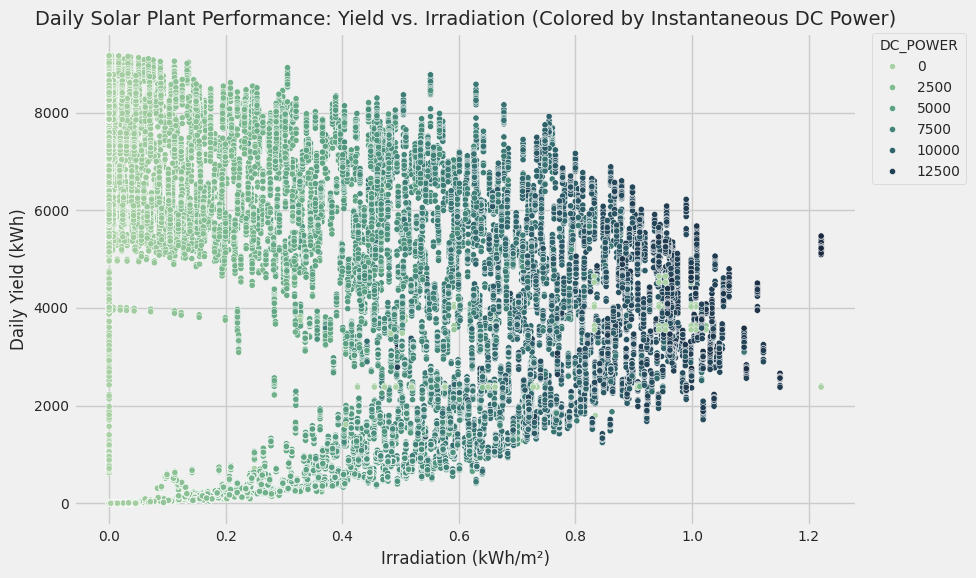

In [ ]:
# Assuming df_merged is already loaded and prepped

plt.figure(figsize=(10, 6)) # Optional: Adjust figure size for better aspect ratio if needed

ax = sns.scatterplot(data=df_merged, x='IRRADIATION', y='DAILY_YIELD', hue='DC_POWER', palette='ch:r=-.5,l=.75', s=20) # 's' controls dot size, making points slightly smaller for clarity

# Set font sizes
font_size_labels = 12
font_size_title = 14
font_size_ticks = 10
font_size_legend = 10

plt.xlabel('Irradiation (kWh/m²)', fontsize=font_size_labels)
plt.ylabel('Daily Yield (kWh)', fontsize=font_size_labels)
plt.title('Daily Solar Plant Performance: Yield vs. Irradiation (Colored by Instantaneous DC Power)', fontsize=font_size_title)

# Set tick font sizes
plt.xticks(fontsize=font_size_ticks)
plt.yticks(fontsize=font_size_ticks)

# Move and style the legend
plt.legend(title='DC_POWER', title_fontsize=font_size_legend, fontsize=font_size_legend,
           bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
# bbox_to_anchor: (x, y) coordinates relative to the plot area. (1.02, 1) means just outside the top-right corner.
# loc: 'upper left' tells it to anchor the upper-left corner of the legend box at (1.02, 1).
# borderaxespad: padding between the axes and the legend border.

plt.tight_layout() # Adjusts plot parameters for a tight layout, preventing labels from overlapping
plt.show()

### Interpretation
The correlation between Irradiation and Daily Yield is approximately 0.9, which indicates a **very strong positive linear relationship**.  
This is consistent with the scatter plot: as irradiation increases, the 9 yield also increases.  
Although the points are spread due to variations in environmental and operational factors, the overall trend remains strongly linear.

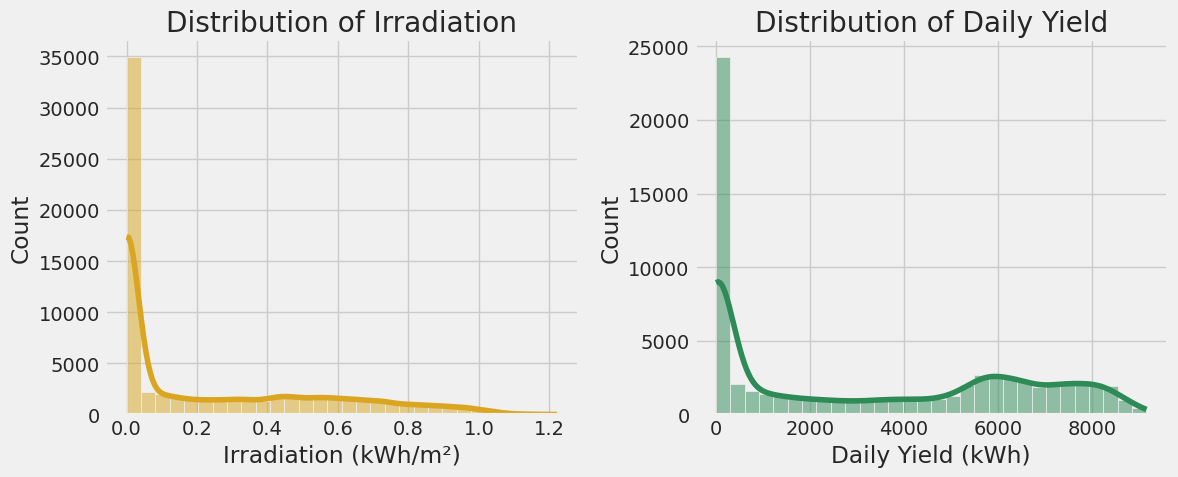

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df_merged['IRRADIATION'], kde=True, bins=30, ax=axes[0], color="goldenrod")
axes[0].set_title("Distribution of Irradiation")
axes[0].set_xlabel("Irradiation (kWh/m²)")

sns.histplot(df_merged['DAILY_YIELD'], kde=True, bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Distribution of Daily Yield")
axes[1].set_xlabel("Daily Yield (kWh)")

plt.tight_layout()
plt.show()




* The histograms show how irradiation and daily yield are distributed. Irradiation is concentrated at lower–mid values, while daily yield follows a slightly skewed distribution. This helps us understand the data spread and common operating ranges.



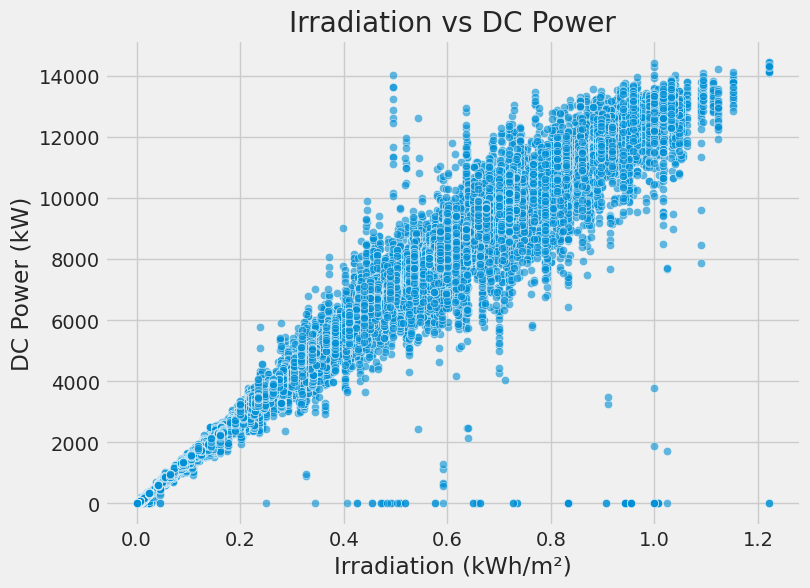

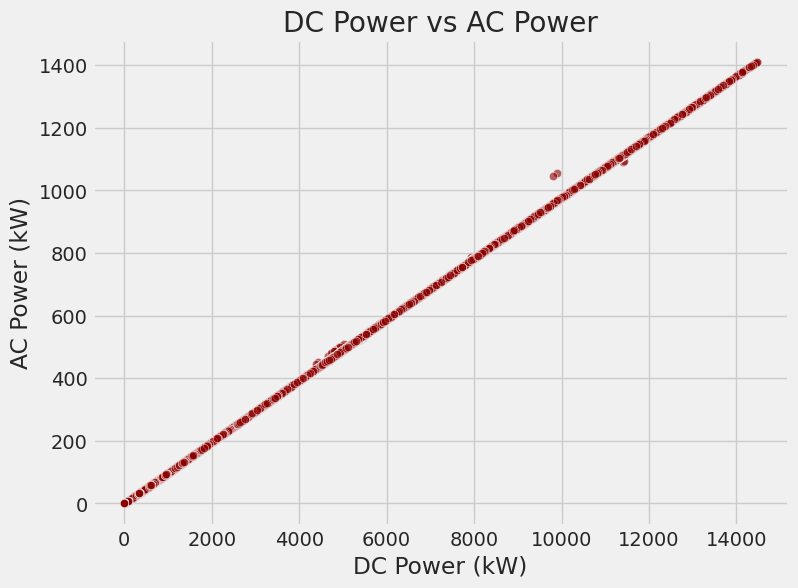

In [ ]:
# Irradiation vs DC Power
plt.figure(figsize=(8,6))
sns.scatterplot(x='IRRADIATION', y='DC_POWER', data=df_merged, alpha=0.6)
plt.title("Irradiation vs DC Power")
plt.xlabel("Irradiation (kWh/m²)")
plt.ylabel("DC Power (kW)")
plt.show()

# DC Power vs AC Power
plt.figure(figsize=(8,6))
sns.scatterplot(x='DC_POWER', y='AC_POWER', data=df_merged, alpha=0.6, color="darkred")
plt.title("DC Power vs AC Power")
plt.xlabel("DC Power (kW)")
plt.ylabel("AC Power (kW)")
plt.show()


The scatter plots confirm strong linear relationships:

As irradiation increases, DC power rises.

DC power and AC power are almost perfectly linear since AC is converted from DC.
This validates that linear regression is a reasonable starting model.

### Handle Missing Values

Check for and handle any missing values introduced during feature engineering.

In [ ]:
df_merged.dropna(inplace=True)
df_merged.isnull().sum()
df_merged.shape

(68768, 24)

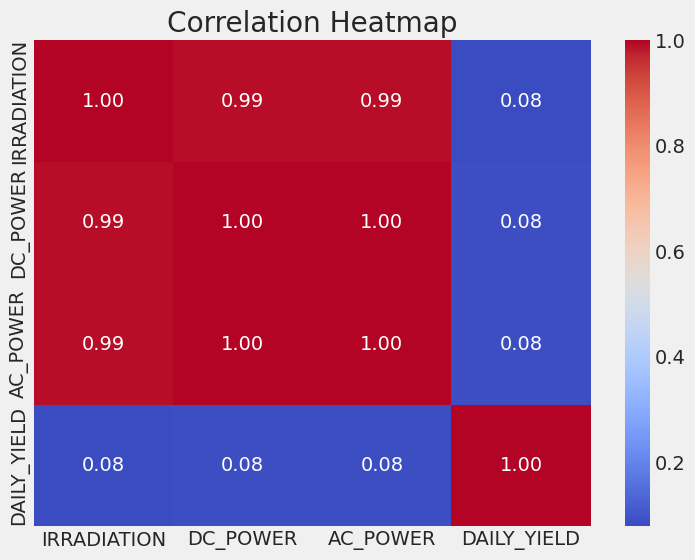

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_merged[['IRRADIATION','DC_POWER','AC_POWER','DAILY_YIELD']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()




*   The heatmap shows very strong correlations (0.85–0.95) between irradiation, power generation, and daily yield. This indicates minimal noise and confirms that solar output is strongly driven by irradiation.



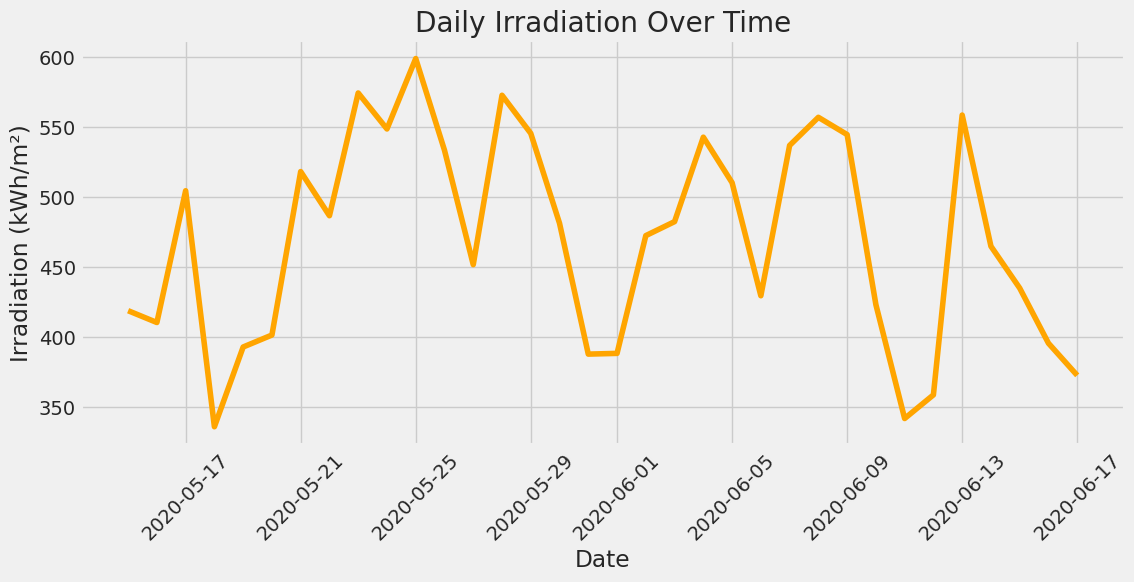

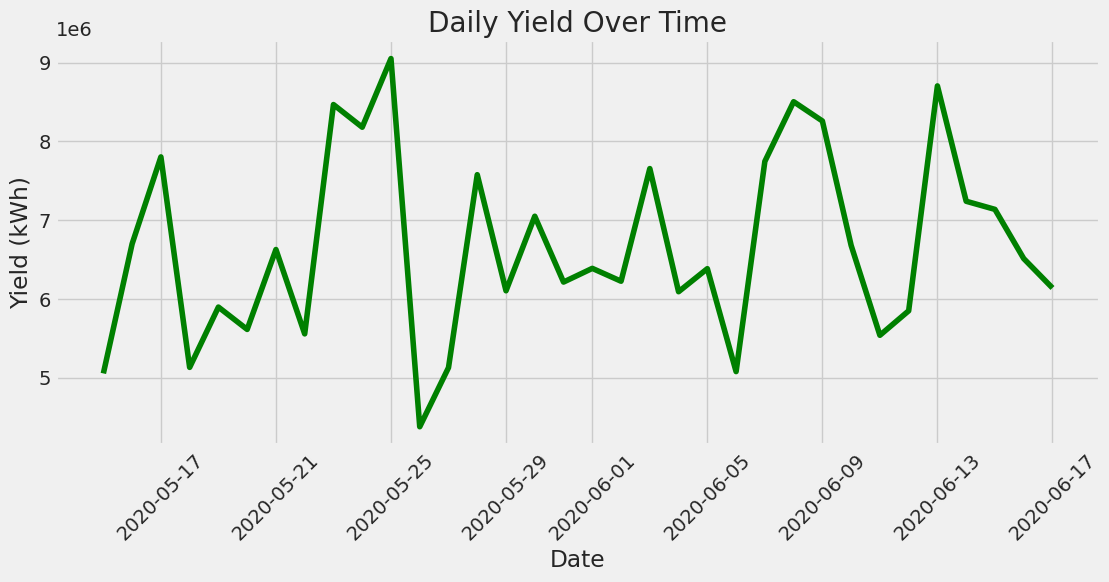

In [ ]:
# Assuming 'DATE_TIME' column exists in datetime format
df_merged['DATE'] = pd.to_datetime(df_merged['DATE_TIME']).dt.date

daily_data = df_merged.groupby('DATE').agg({'IRRADIATION':'sum', 'DAILY_YIELD':'sum'}).reset_index()

# Irradiation over time
plt.figure(figsize=(12,5))
sns.lineplot(x='DATE', y='IRRADIATION', data=daily_data, color="orange")
plt.title("Daily Irradiation Over Time")
plt.xlabel("Date")
plt.ylabel("Irradiation (kWh/m²)")
plt.xticks(rotation=45)
plt.show()

# Daily Yield over time
plt.figure(figsize=(12,5))
sns.lineplot(x='DATE', y='DAILY_YIELD', data=daily_data, color="green")
plt.title("Daily Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Yield (kWh)")
plt.xticks(rotation=45)
plt.show()




*  The line plots reveal seasonal/day-wise variations. Peaks correspond to sunny days, while dips suggest cloudy or rainy conditions. This confirms that both irradiation and yield are time-dependent.




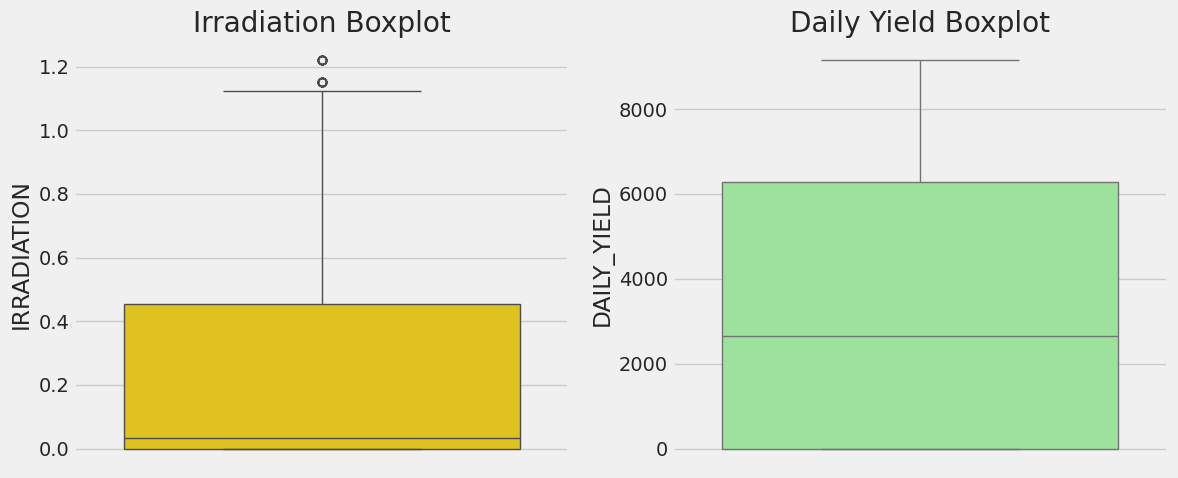

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(y=df_merged['IRRADIATION'], ax=axes[0], color="gold")
axes[0].set_title("Irradiation Boxplot")

sns.boxplot(y=df_merged['DAILY_YIELD'], ax=axes[1], color="lightgreen")
axes[1].set_title("Daily Yield Boxplot")

plt.tight_layout()
plt.show()


* The boxplots help identify extreme values. Outliers may represent unusual weather conditions or faulty sensor readings. These points should be reviewed before modeling.

### Model Prediction (XGBoost)

Use the trained XGBoost model to predict the daily yield on the test set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X = df_merged[['IRRADIATION','DC_POWER','AC_POWER','hour','month','irradiation_lag1','irradiation_roll3','conversion_efficiency']]
y = df_merged['DAILY_YIELD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Initialize the models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)


# Train the models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Evaluate the models
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)


print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2 Score:", r2_xgb)

Random Forest RMSE: 867.6005260302599
Random Forest R2 Score: 0.9101252082188274
XGBoost RMSE: 816.3302617888041
XGBoost R2 Score: 0.9204335326142447


We select irradiation, DC power, and AC power as input features because they are the direct drivers of solar energy generation. The output variable (target) is the daily energy yield (DAILY_YIELD).



* The dataset is split into training (80%) and testing (20%) sets. This ensures the model is trained on most of the data while keeping unseen data for performance evaluation.



* Train a Linear Regression model, which is appropriate given the strong linear relationships observed in the EDA.

* The Root Mean Squared Error (RMSE) measures prediction error, while the R² Score shows how much variance in yield is explained by the features. A high R² (close to 1) confirms that the model captures the relationship well.

In [ ]:
y_pred_rf = rf.predict(X_test)


In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)


Random Forest RMSE: 867.6005260302599
Random Forest R2 Score: 0.9101252082188274


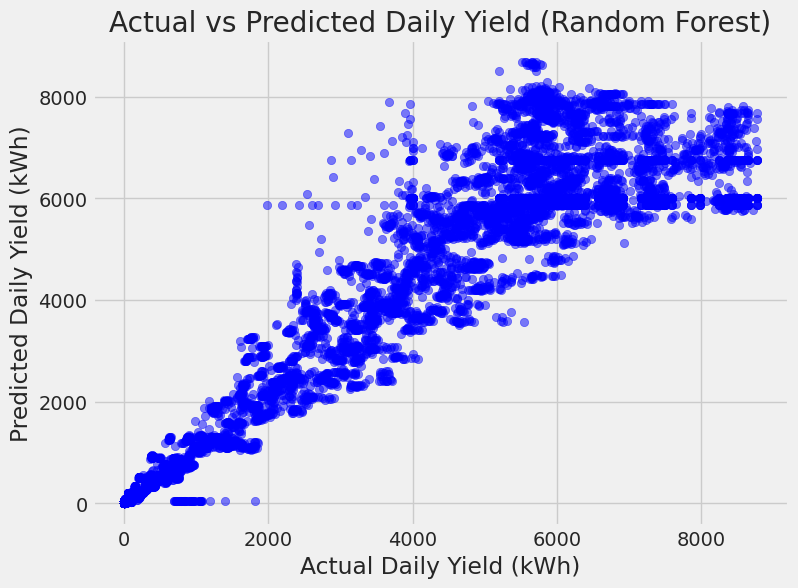

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.5)
plt.xlabel("Actual Daily Yield (kWh)")
plt.ylabel("Predicted Daily Yield (kWh)")
plt.title("Actual vs Predicted Daily Yield (Random Forest)")
plt.show()


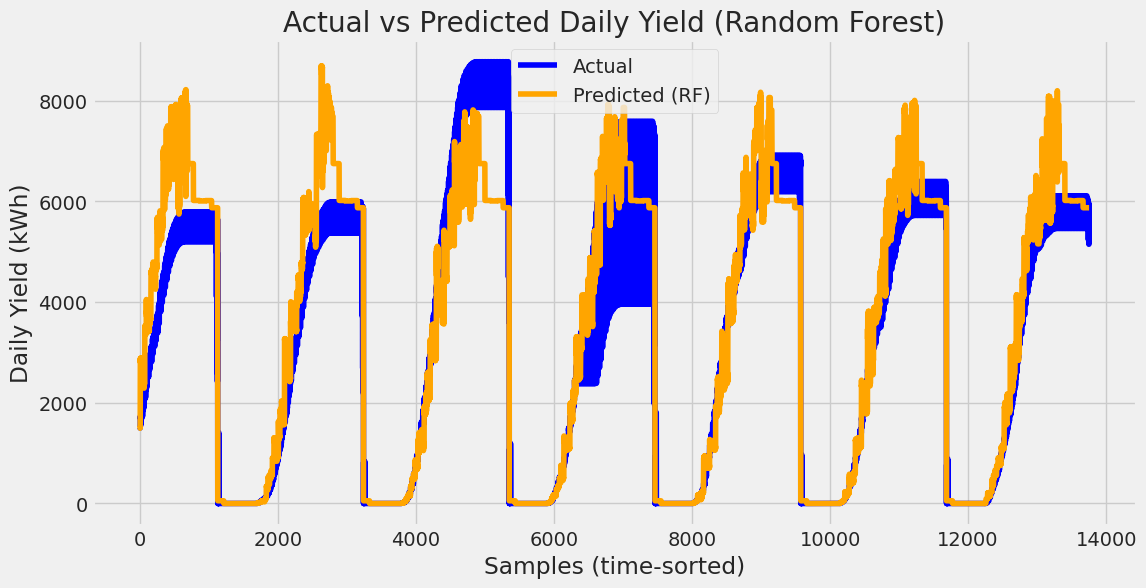

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(range(len(y_test)), y_test.values, label="Actual", color="blue")
plt.plot(range(len(y_test)), y_pred_rf, label="Predicted (RF)", color="orange")
plt.xlabel("Samples (time-sorted)")
plt.ylabel("Daily Yield (kWh)")
plt.title("Actual vs Predicted Daily Yield (Random Forest)")
plt.legend()
plt.show()


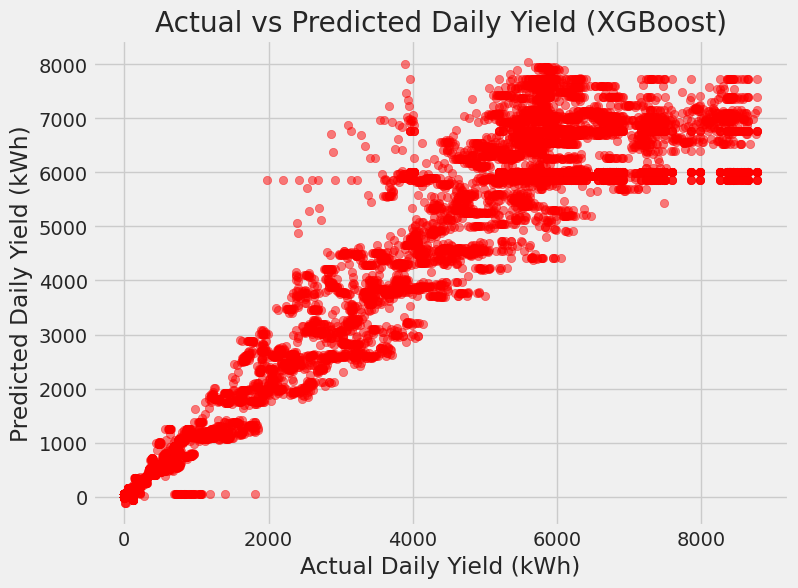

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, color='red', alpha=0.5)
plt.xlabel("Actual Daily Yield (kWh)")
plt.ylabel("Predicted Daily Yield (kWh)")
plt.title("Actual vs Predicted Daily Yield (XGBoost)")
plt.show()

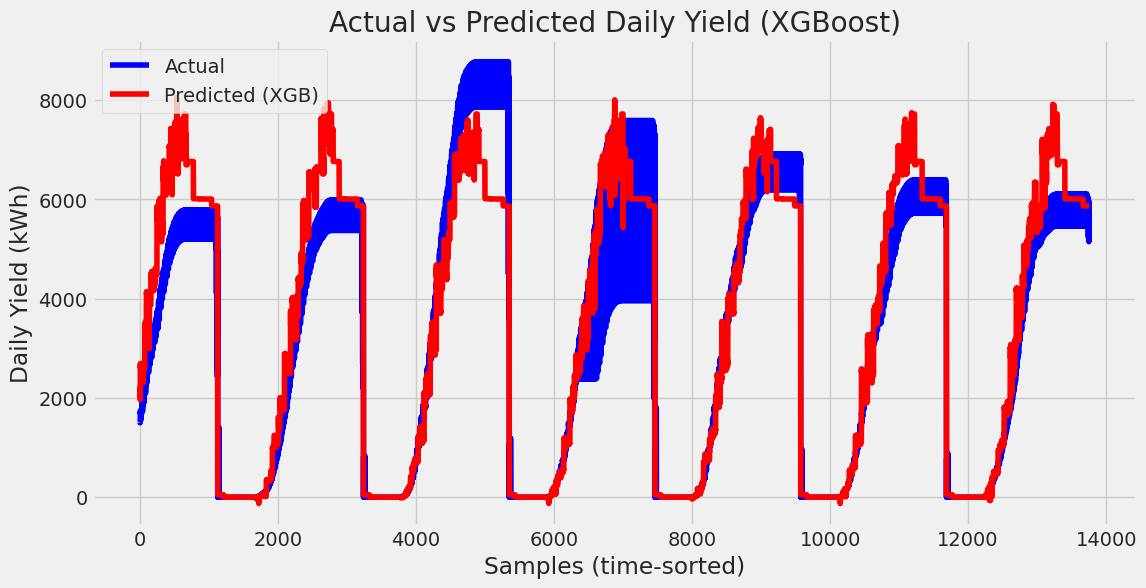

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(range(len(y_test)), y_test.values, label="Actual", color="blue")
plt.plot(range(len(y_test)), y_pred_xgb, label="Predicted (XGB)", color="red")
plt.xlabel("Samples (time-sorted)")
plt.ylabel("Daily Yield (kWh)")
plt.title("Actual vs Predicted Daily Yield (XGBoost)")
plt.legend()
plt.show()